In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("hr_data.xls", encoding="utf-8-sig")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
print(df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

(1470, 35)
Missing values: 0
Duplicate rows: 0


### Data Preprocessing & Exploratory Data Analysis (EDA)

In [7]:
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True))
sns.countplot(data=df, x="Attrition")
plt.show()

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


<Figure size 640x480 with 1 Axes>

In [8]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [9]:
df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"])
print(df.shape)

(1470, 31)


In [10]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(cat_cols)

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [11]:
for col in cat_cols:
    print(df.groupby(col)["Attrition"].mean().sort_values(ascending=False).round(3))
    print()

BusinessTravel
Travel_Frequently    0.249
Travel_Rarely        0.150
Non-Travel           0.080
Name: Attrition, dtype: float64

Department
Sales                     0.206
Human Resources           0.190
Research & Development    0.138
Name: Attrition, dtype: float64

EducationField
Human Resources     0.259
Technical Degree    0.242
Marketing           0.220
Life Sciences       0.147
Medical             0.136
Other               0.134
Name: Attrition, dtype: float64

Gender
Male      0.170
Female    0.148
Name: Attrition, dtype: float64

JobRole
Sales Representative         0.398
Laboratory Technician        0.239
Human Resources              0.231
Sales Executive              0.175
Research Scientist           0.161
Manufacturing Director       0.069
Healthcare Representative    0.069
Manager                      0.049
Research Director            0.025
Name: Attrition, dtype: float64

MaritalStatus
Single      0.255
Married     0.125
Divorced    0.101
Name: Attrition, dtype: float64

In [12]:
num_cols = df.select_dtypes(include="number").columns.drop("Attrition").tolist()
print(df.groupby("Attrition")[num_cols].mean().T.round(2))

Attrition                        0         1
Age                          37.56     33.61
DailyRate                   812.50    750.36
DistanceFromHome              8.92     10.63
Education                     2.93      2.84
EnvironmentSatisfaction       2.77      2.46
HourlyRate                   65.95     65.57
JobInvolvement                2.77      2.52
JobLevel                      2.15      1.64
JobSatisfaction               2.78      2.47
MonthlyIncome              6832.74   4787.09
MonthlyRate               14265.78  14559.31
NumCompaniesWorked            2.65      2.94
PercentSalaryHike            15.23     15.10
PerformanceRating             3.15      3.16
RelationshipSatisfaction      2.73      2.60
StockOptionLevel              0.85      0.53
TotalWorkingYears            11.86      8.24
TrainingTimesLastYear         2.83      2.62
WorkLifeBalance               2.78      2.66
YearsAtCompany                7.37      5.13
YearsInCurrentRole            4.48      2.90
YearsSince

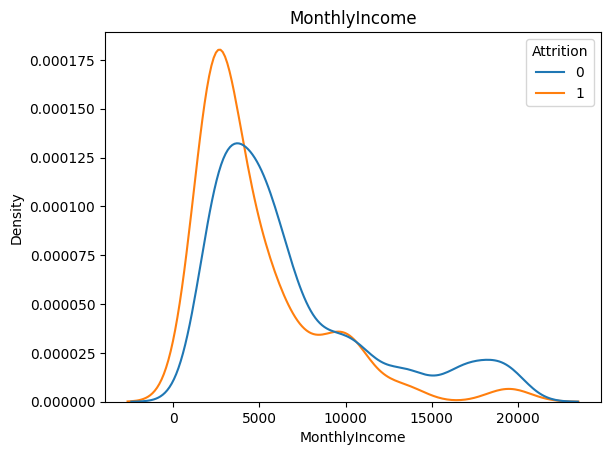

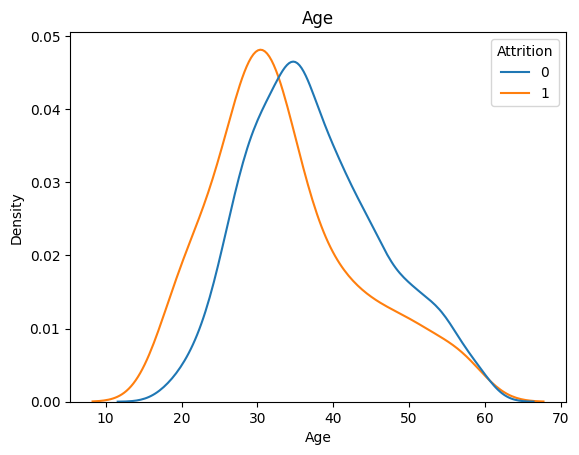

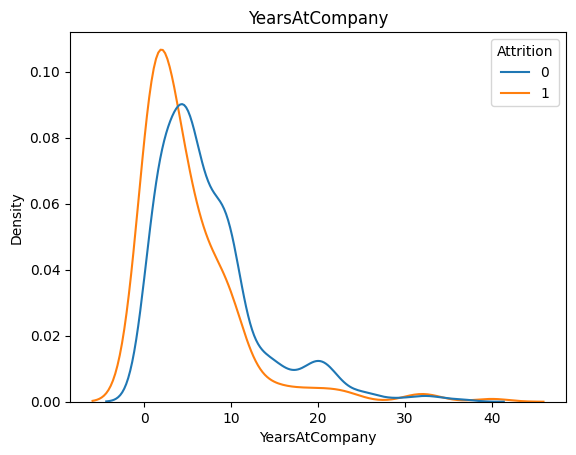

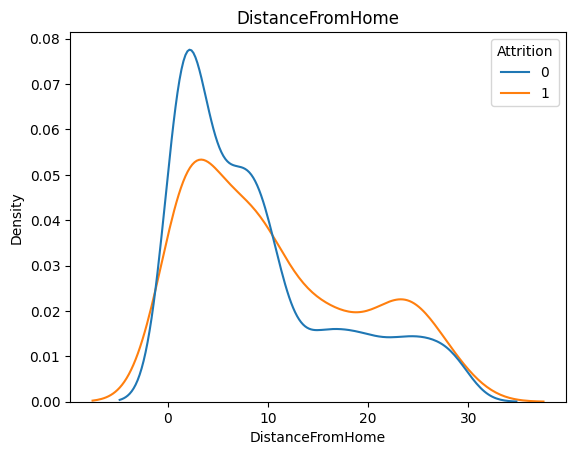

In [13]:
for col in ["MonthlyIncome", "Age", "YearsAtCompany", "DistanceFromHome"]:
    sns.kdeplot(data=df, x=col, hue="Attrition", common_norm=False)
    plt.title(col)
    plt.show()

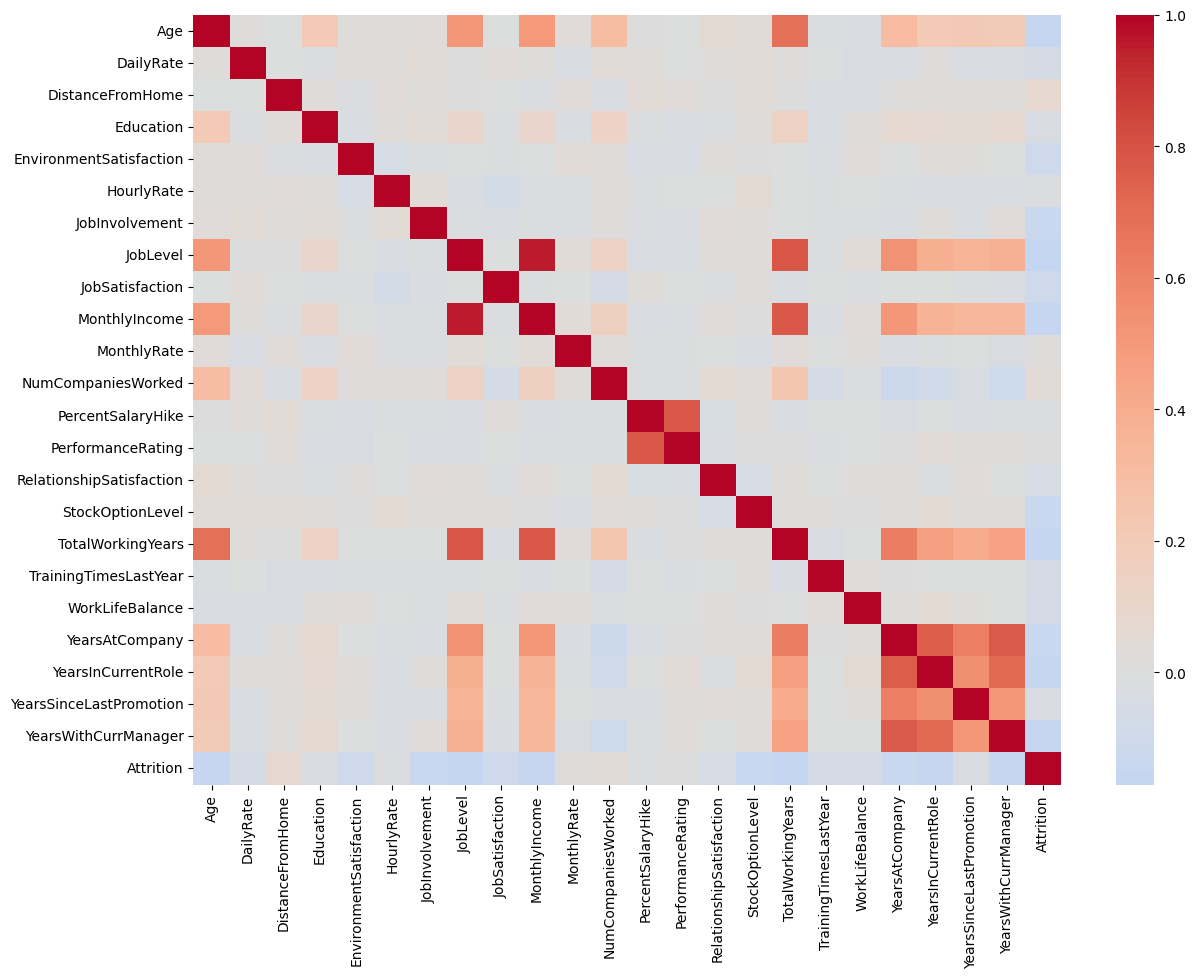

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols + ["Attrition"]].corr(), cmap="coolwarm", center=0)
plt.show()

In [15]:
df.groupby( 'OverTime')["Attrition"].mean()

OverTime
No     0.104364
Yes    0.305288
Name: Attrition, dtype: float64

Model Training & AutoML

In [16]:
X = df.drop(columns="Attrition")
y = df["Attrition"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(1176, 30) (294, 30)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
cat_cols =X.select_dtypes(include='object').columns.to_list()
num_cols  = X.select_dtypes(include='number').columns.to_list()

num_pipe= Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',StandardScaler())
])


cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('oneHot',OneHotEncoder(handle_unknown='ignore', sparse=True))
])


preprocessor = ColumnTransformer([
    ('num',num_pipe,num_cols),
    ('cat',cat_pipe,cat_cols)
])

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [21]:
models={
    "Logistic Regression" : LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest" : RandomForestClassifier(n_estimators=300, class_weight='balanced')
}
for name,clf in models.items():
   pipe = Pipeline([('prep',preprocessor),('model',clf)])
   pipe.fit(X_train, y_train)
   pred  = pipe.predict(X_test)
   proba = pipe.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

              precision    recall  f1-score   support

           0      0.853     0.988     0.916       247
           1      0.625     0.106     0.182        47

    accuracy                          0.847       294
   macro avg      0.739     0.547     0.549       294
weighted avg      0.817     0.847     0.798       294

ROC-AUC: 0.778


In [22]:
import pycaret

In [23]:
from pycaret.classification import *

In [24]:
s = setup(
    data=df,
    target="Attrition",
    session_id=42,
    train_size=0.8,
    fix_imbalance=True,
    normalize=True,
    fold=5,
)

,Description,Value
0,Session id,42
1,Target,Attrition
2,Target type,Binary
3,Original data shape,"(1470, 31)"
4,Transformed data shape,"(2266, 50)"
5,Transformed train set shape,"(1972, 50)"
6,Transformed test set shape,"(294, 50)"
7,Numeric features,23
8,Categorical features,7
9,Preprocess,True


In [27]:
best_models = compare_models(sort="AUC", n_select=3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.7611,0.8249,0.7316,0.3805,0.4984,0.3629,0.3980,0.0780
ridge,Ridge Classifier,0.7611,0.8248,0.7316,0.3805,0.4984,0.3629,0.3980,0.2200
lr,Logistic Regression,0.7704,0.8236,0.7211,0.3889,0.5034,0.3718,0.4034,2.2640
rf,Random Forest Classifier,0.8690,0.7997,0.2789,0.7637,0.4073,0.3511,0.4084,0.5980
et,Extra Trees Classifier,0.8699,0.7966,0.3053,0.7411,0.4314,0.3719,0.4194,0.2200
gbc,Gradient Boosting Classifier,0.8657,0.7926,0.3895,0.6453,0.4810,0.4098,0.4295,0.5380
ada,Ada Boost Classifier,0.8478,0.7763,0.5000,0.5353,0.5127,0.4234,0.4262,0.2720
svm,SVM - Linear Kernel,0.7398,0.7702,0.6263,0.3457,0.4436,0.2950,0.3165,0.3500
nb,Naive Bayes,0.5902,0.7360,0.7579,0.2523,0.3776,0.1775,0.2341,0.6040
knn,K Neighbors Classifier,0.6454,0.7034,0.6947,0.2697,0.3878,0.2023,0.2477,1.2880


In [30]:
best = best_models[2]
tuned = tune_model(best, optimize="F1", n_iter=30)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7373,0.7273,0.5789,0.3235,0.4151,0.2628,0.2813
1,0.7404,0.8584,0.8684,0.3708,0.5197,0.3789,0.4434
2,0.7787,0.8314,0.6842,0.3939,0.5000,0.3709,0.3942
3,0.7830,0.8302,0.6579,0.3968,0.4950,0.3674,0.3865
4,0.8213,0.8707,0.8158,0.4697,0.5962,0.4919,0.5228
Mean,0.7721,0.8236,0.7211,0.3910,0.5052,0.3744,0.4056
Std,0.0310,0.0506,0.1060,0.0473,0.0578,0.0726,0.0789


Fitting 5 folds for each of 30 candidates, totalling 150 fits


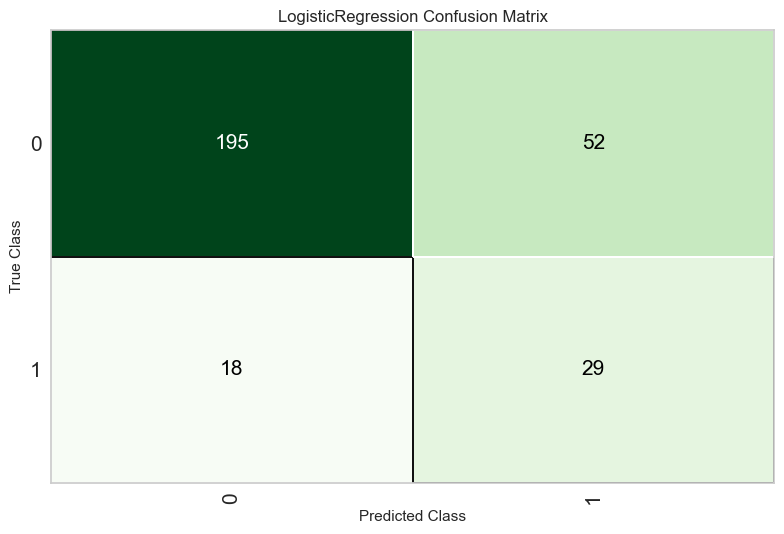

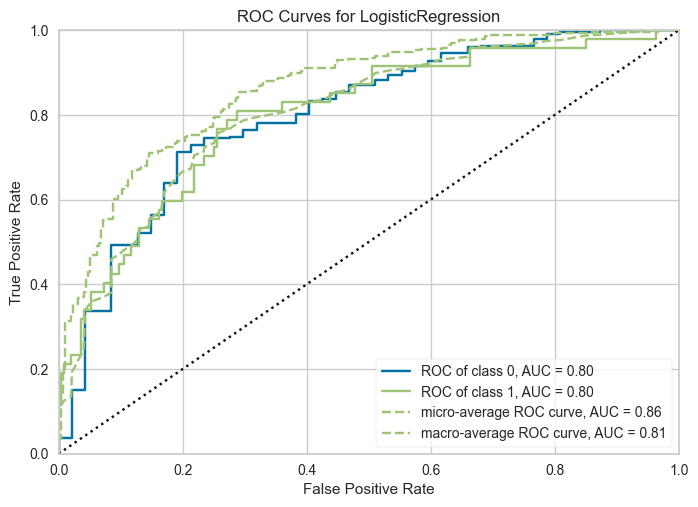

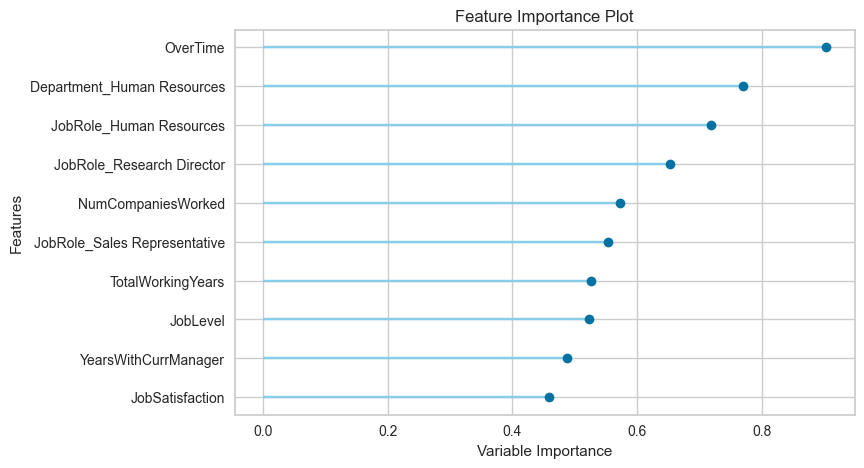

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7619,0.8004,0.6170,0.3580,0.4531,0.3144,0.3334


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,prediction_label,prediction_score
1061,24,Non-Travel,830,Sales,13,2,Life Sciences,4,Female,78,...,1,2,3,1,0,0,0,0,0,0.6783
891,44,Travel_Rarely,1117,Research & Development,2,1,Life Sciences,1,Female,72,...,10,5,3,10,5,7,7,0,0,0.9939
456,31,Travel_Rarely,688,Sales,7,3,Life Sciences,3,Male,44,...,10,3,2,5,4,0,1,0,0,0.7917
922,44,Travel_Rarely,1199,Research & Development,4,2,Life Sciences,3,Male,92,...,26,4,2,25,9,14,13,0,0,0.9791
69,36,Travel_Rarely,318,Research & Development,9,3,Medical,4,Male,79,...,2,0,2,1,0,0,0,1,1,0.6605


In [31]:
plot_model(tuned, plot="confusion_matrix")
plot_model(tuned, plot="auc")
plot_model(tuned, plot="feature")

holdout = predict_model(tuned)
holdout.head()

Logistic Regression ranked 3rd by AUC (0.8236), essentially tied with LDA (0.8249) and Ridge (0.8248). Tree models had high accuracy (~0.87) but low recall (0.28 to 0.39). I chose Logistic Regression because it has strong recall (0.72), gives probabilities, and is highly interpretable. Tuning for F1 changed CV F1 only from 0.503 to 0.505, so the default settings were already near-optimal. On the PyCaret hold-out set the tuned model scored AUC 0.800, Recall 0.617, Precision 0.358, F1 0.453.

In [35]:
final = finalize_model(tuned)
save_model(final, "pycaret_attrition_model")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age', 'DailyRate',
                                              'DistanceFromHome', 'Education',
                                              'EnvironmentSatisfaction',
                                              'HourlyRate', 'JobInvolvement',
                                              'JobLevel', 'JobSatisfaction',
                                              'MonthlyIncome', 'MonthlyRate',
                                              'NumCompaniesWorked',
                                              'PercentSalaryHike',
                                              'PerformanceRating',
                                              'RelationshipSatis...
                                     transformer=StandardScaler(copy=True,
                                                                with_mean=

In [45]:
import shap

X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)
feature_names = [n.split("__", 1)[1] for n in preprocessor.get_feature_names_out()]

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_t, y_train)

explainer   = shap.LinearExplainer(lr, X_train_t)
shap_values = explainer(X_test_t)
shap_values.feature_names = feature_names

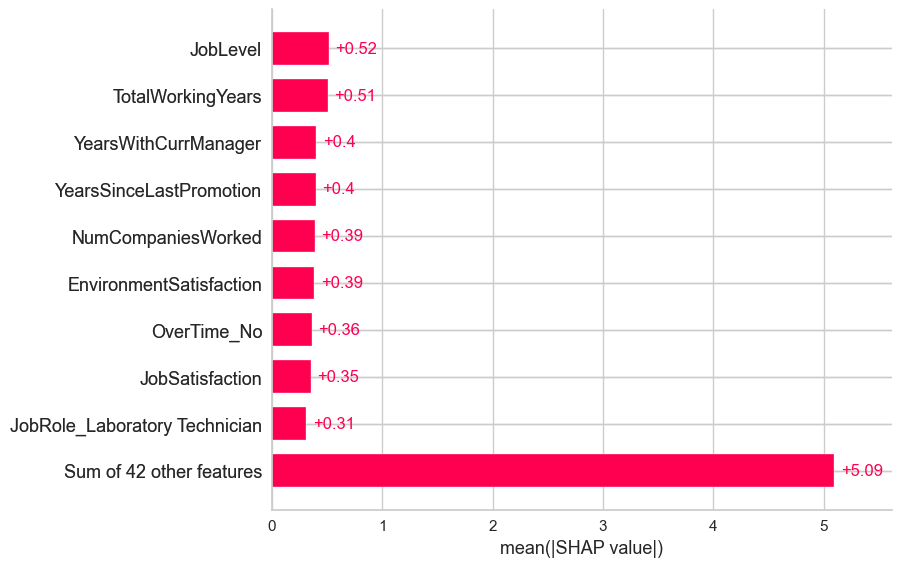

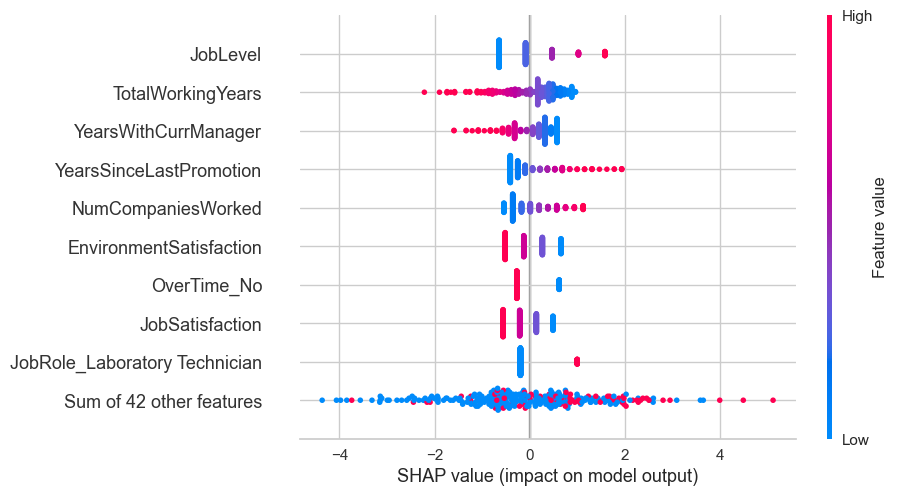

In [40]:
shap.plots.bar(shap_values, max_display=10)
shap.plots.beeswarm(shap_values, max_display=10)

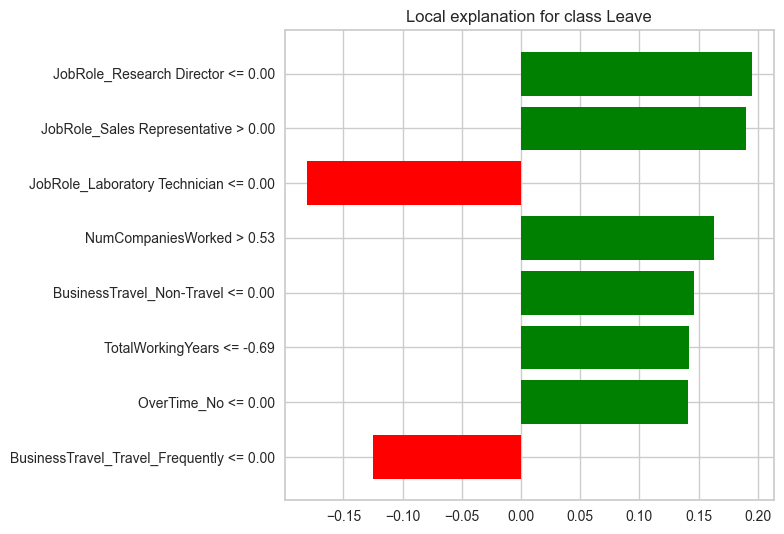

In [46]:
from lime.lime_tabular import LimeTabularExplainer

# set up LIME (just copy this)
lime_exp = LimeTabularExplainer(
    X_train_t,
    feature_names=feature_names,
    class_names=["Stay", "Leave"],
    mode="classification",
    random_state=42,
)

# choose which employee to explain (any number from 0 to 293)
i = 20

# ask LIME: why did the model give this prediction?
exp = lime_exp.explain_instance(X_test_t[i], lr.predict_proba, num_features=8)

# draw the answer as a chart
exp.as_pyplot_figure()
plt.tight_layout()
plt.show()